<a href="https://colab.research.google.com/github/pjastr-uwm/fakultet_io_2026/blob/main/lab07/lab07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Klasyczna klasyfikacja tekstu — Analiza sentymentu
## Pipeline: Przetwarzanie → Wektoryzacja (TF-IDF) → Klasyfikator → Ewaluacja

**Dataset:** PolEmo 2.0 — zbiór polskich recenzji konsumenckich z czterech domen: medycyna, hotele, produkty i szkoła.

**Etykiety sentymentu:**
- `minus` — negatywny
- `zero` — neutralny
- `plus` — pozytywny
- `amb` — ambiwalentny



# 1. Instalacja i import bibliotek

Instalujemy niezbędne pakiety, które mogą nie być dostępne domyślnie w Google Colab.


In [ ]:
# Instalacja pakietów (wystarczy uruchomić raz)
!pip install datasets -q


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score
)

print("Wszystkie biblioteki załadowane pomyślnie ✓")


Wszystkie biblioteki załadowane pomyślnie ✓


# 2. Ładowanie datasetu PolEmo 2.0

Korzystamy z wersji datasetu udostępnionej przez Allegro (benchmark KLEJ) na Hugging Face.

Dataset zawiera kolumny:
- `sentence` — treść recenzji
- `target` — etykieta sentymentu (tekstowa: `minus`, `zero`, `plus`, `amb`)


In [ ]:
# Ładowanie datasetu PolEmo 2.0 z Hugging Face
dataset = load_dataset("allegro/klej-polemo2-in")

print("Struktura datasetu:")
print(dataset)
print()
print("Przykładowy rekord:")
print(dataset['train'][0])


Struktura datasetu:
DatasetDict({
    train: Dataset({
        features: ['sentence', 'target'],
        num_rows: 5783
    })
    validation: Dataset({
        features: ['sentence', 'target'],
        num_rows: 723
    })
    test: Dataset({
        features: ['sentence', 'target'],
        num_rows: 722
    })
})

Przykładowy rekord:
{'sentence': 'Super lekarz i człowiek przez duże C . Bardzo duże doświadczenie i trafne diagnozy . Wielka cierpliwość do ludzi starszych . Od lat opiekuje się moją Mamą staruszką , i twierdzę , że mamy duże szczęście , że mamy takiego lekarza . Naprawdę nie wiem cobyśmy zrobili , gdyby nie Pan doktor . Dzięki temu , moja mama żyje . Każda wizyta u specjalisty jest u niego konsultowana i uważam , że jest lepszy od każdego z nich . Mamy do Niego prawie nieograniczone zaufanie . Można wiele dobrego o Panu doktorze jeszcze napisać . Niestety , ma bardzo dużo pacjentów , jest przepracowany ( z tego powodu nawet obawiam się o jego zdrowie ) i dostęp do niego 

In [ ]:
# Konwersja do pandas DataFrame
df_train = pd.DataFrame(dataset['train'])
df_val = pd.DataFrame(dataset['validation'])
df_test = pd.DataFrame(dataset['test'])

print("Kolumny:", df_train.columns.tolist())
print(f"Rozmiary: train={len(df_train)}, val={len(df_val)}, test={len(df_test)}")
print()

# Sprawdzenie unikatowych etykiet
print("Unikatowe wartości 'target':", df_train['target'].unique())
print()
print("Rozkład klas w zbiorze treningowym:")
print(df_train['target'].value_counts())


Kolumny: ['sentence', 'target']
Rozmiary: train=5783, val=723, test=722

Unikatowe wartości 'target': ['__label__meta_plus_m' '__label__meta_minus_m' '__label__meta_amb'
 '__label__meta_zero']

Rozkład klas w zbiorze treningowym:
target
__label__meta_minus_m    2194
__label__meta_plus_m     1568
__label__meta_amb        1050
__label__meta_zero        971
Name: count, dtype: int64


In [ ]:
# Mapowanie etykiet tekstowych na czytelne polskie nazwy
label_names = {
    'minus': 'negatywny',
    'zero': 'neutralny',
    'plus': 'pozytywny',
    'amb': 'ambiwalentny',
    # Na wypadek gdyby etykiety były w formacie __label__meta_*
    '__label__meta_minus_m': 'negatywny',
    '__label__meta_zero': 'neutralny',
    '__label__meta_plus_m': 'pozytywny',
    '__label__meta_amb': 'ambiwalentny',
}

# Kolory przypisane do etykiet
label_colors = {
    'negatywny': '#e74c3c',
    'neutralny': '#95a5a6',
    'pozytywny': '#2ecc71',
    'ambiwalentny': '#f39c12'
}

# Dodajemy kolumnę z czytelną nazwą klasy
for df in [df_train, df_val, df_test]:
    df['label_name'] = df['target'].map(label_names).fillna(df['target'])

print("Mapowanie etykiet:")
for orig, name in sorted(set(zip(df_train['target'], df_train['label_name']))):
    print(f"  '{orig}' → '{name}'")


Mapowanie etykiet:
  '__label__meta_amb' → 'ambiwalentny'
  '__label__meta_minus_m' → 'negatywny'
  '__label__meta_plus_m' → 'pozytywny'
  '__label__meta_zero' → 'neutralny'


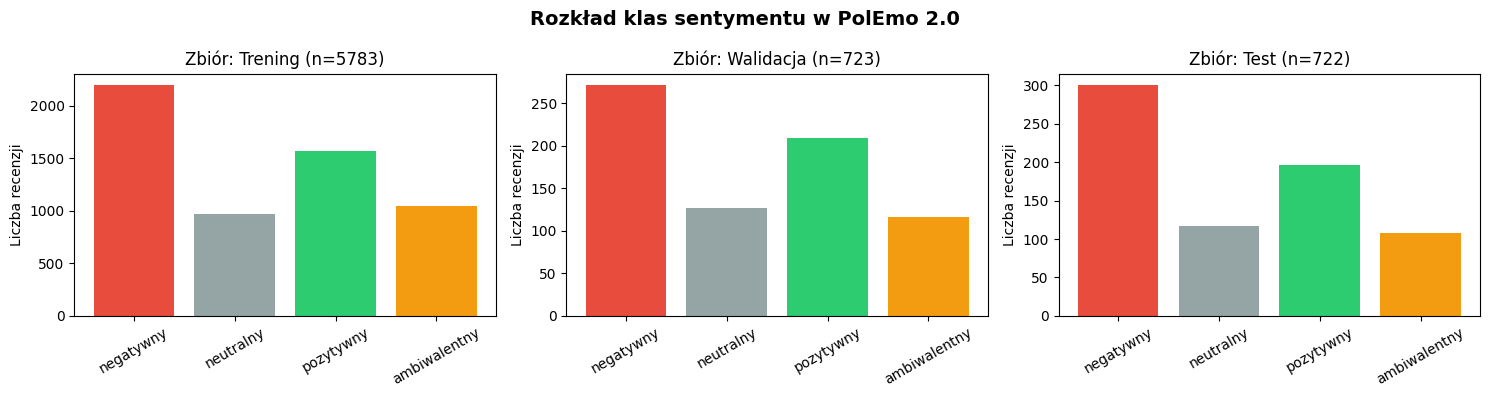

In [ ]:
# Wizualizacja rozkładu klas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, df) in zip(axes, [('Trening', df_train), ('Walidacja', df_val), ('Test', df_test)]):
    counts = df['label_name'].value_counts()
    # Sortujemy w stałej kolejności
    order = ['negatywny', 'neutralny', 'pozytywny', 'ambiwalentny']
    order = [o for o in order if o in counts.index]
    counts = counts.reindex(order)
    colors = [label_colors.get(o, '#999999') for o in order]
    ax.bar(counts.index, counts.values, color=colors)
    ax.set_title(f'Zbiór: {name} (n={len(df)})')
    ax.set_ylabel('Liczba recenzji')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Rozkład klas sentymentu w PolEmo 2.0', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# 3. Eksploracja danych (EDA)

Przed budową modelu warto przyjrzeć się danym — długość tekstów, przykłady z poszczególnych klas.


In [ ]:
# Ustalenie kolumny tekstowej
text_col = 'sentence' if 'sentence' in df_train.columns else 'text'
print(f"Kolumna tekstowa: '{text_col}'")

# Długość tekstów (w znakach i słowach)
df_train['char_len'] = df_train[text_col].str.len()
df_train['word_count'] = df_train[text_col].str.split().str.len()

print("\nStatystyki długości tekstów (treningowe):")
print(df_train[['char_len', 'word_count']].describe().round(1))


Kolumna tekstowa: 'sentence'

Statystyki długości tekstów (treningowe):
       char_len  word_count
count    5783.0      5783.0
mean      780.6       137.1
std       433.1        77.5
min         1.0         1.0
25%       483.0        85.0
50%       698.0       121.0
75%       942.0       161.5
max      5391.0       987.0


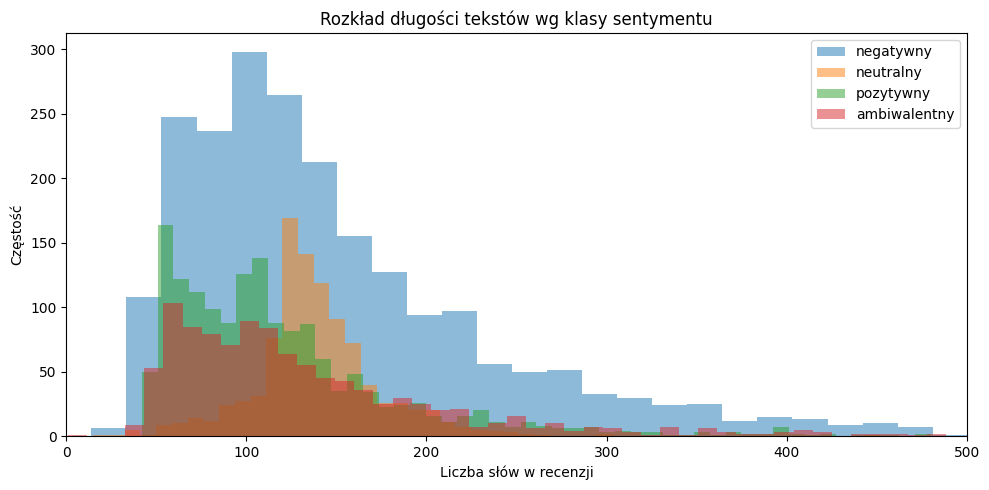

In [ ]:
# Rozkład długości tekstów wg klasy sentymentu
fig, ax = plt.subplots(figsize=(10, 5))
for label_name in ['negatywny', 'neutralny', 'pozytywny', 'ambiwalentny']:
    subset = df_train[df_train['label_name'] == label_name]
    if len(subset) > 0:
        ax.hist(subset['word_count'], bins=50, alpha=0.5, label=label_name)

ax.set_xlabel('Liczba słów w recenzji')
ax.set_ylabel('Częstość')
ax.set_title('Rozkład długości tekstów wg klasy sentymentu')
ax.legend()
ax.set_xlim(0, 500)
plt.tight_layout()
plt.show()


In [ ]:
# Przykłady tekstów z każdej klasy
for label_name in ['negatywny', 'neutralny', 'pozytywny', 'ambiwalentny']:
    subset = df_train[df_train['label_name'] == label_name]
    if len(subset) > 0:
        example = subset[text_col].iloc[0]
        print(f"--- {label_name.upper()} ---")
        print(example[:300] + "..." if len(example) > 300 else example)
        print()


--- NEGATYWNY ---
Bardzo olewcze podejscie do pacjenta . Przyprowadzajac dziecko z ostra wysypka na calym ciele trwajaca od 2 tygodni Pani doktor stwierdzila ze nie widzi wskazan wystawienia dziecku skierowania na testy skorne . Chocby na nasza prosbe i dodam iz w prywatnej klinice ( gdzie tak czy siak musielibysmy z...

--- NEUTRALNY ---
" Konsumenci oczywiście kierują się ceną . Te leki są tańsze , ale dzisiaj nie możemy już powiedzieć , że znacznie tańsze . Jest to mniej krępujące , nie trzeba wychodzić z domu , nie trzeba udawać się do lekarza czy prosić o receptę . W takich przypadkach kupujący nie kieruje się zdrowym rozsądkiem...

--- POZYTYWNY ---
Super lekarz i człowiek przez duże C . Bardzo duże doświadczenie i trafne diagnozy . Wielka cierpliwość do ludzi starszych . Od lat opiekuje się moją Mamą staruszką , i twierdzę , że mamy duże szczęście , że mamy takiego lekarza . Naprawdę nie wiem cobyśmy zrobili , gdyby nie Pan doktor . Dzięki tem...

--- AMBIWALENTNY ---
Lekarz zal

# 4. Przygotowanie danych do modelowania

Przygotowujemy wektory tekstów (`X`) i etykiety (`y`) dla zbiorów treningowego i testowego.

Na tym etapie stosujemy podstawowe przetwarzanie wstępne (preprocessing).


In [ ]:
import re

def preprocess_text(text):
    """Podstawowy preprocessing tekstu polskiego."""
    # Zamiana na małe litery
    text = text.lower()
    # Usunięcie znaków specjalnych (zostawiamy polskie litery)
    text = re.sub(r'[^a-ząćęłńóśźżA-ZĄĆĘŁŃÓŚŹŻ\s]', ' ', text)
    # Usunięcie wielokrotnych spacji
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Zastosowanie preprocessingu
X_train = df_train[text_col].apply(preprocess_text).values
y_train = df_train['target'].values

X_test = df_test[text_col].apply(preprocess_text).values
y_test = df_test['target'].values

X_val = df_val[text_col].apply(preprocess_text).values
y_val = df_val['target'].values

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print()
print("Unikatowe etykiety:", np.unique(y_train))
print()
print("Przykład po preprocessingu:")
print(X_train[0][:200])


X_train: (5783,), y_train: (5783,)
X_test:  (722,), y_test:  (722,)
X_val:   (723,), y_val:   (723,)

Unikatowe etykiety: ['__label__meta_amb' '__label__meta_minus_m' '__label__meta_plus_m'
 '__label__meta_zero']

Przykład po preprocessingu:
super lekarz i człowiek przez duże c bardzo duże doświadczenie i trafne diagnozy wielka cierpliwość do ludzi starszych od lat opiekuje się moją mamą staruszką i twierdzę że mamy duże szczęście że mamy


# 5. Pipeline klasyfikacji — Naive Bayes (Baseline)

Zaczynamy od Naive Bayesa jako baseline'u — jest najszybszy i sprawdza się dobrze nawet na niewielkich zbiorach.

Kluczowe elementy pipeline'u:
1. **TfidfVectorizer** — wektoryzacja TF-IDF z bigramami
2. **MultinomialNB** — klasyfikator Naive Bayes z wygładzaniem Laplace'a


In [ ]:
# Pipeline: TF-IDF + Naive Bayes
pipeline_nb = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),    # unigramy + bigramy
        min_df=2,
        sublinear_tf=True      # logarytmiczne skalowanie TF
    )),
    ('clf', MultinomialNB(alpha=1.0))
])

# Trening
pipeline_nb.fit(X_train, y_train)

# Predykcja na zbiorze testowym
y_pred_nb = pipeline_nb.predict(X_test)

# Raport klasyfikacji
print("=" * 60)
print("NAIVE BAYES — Raport klasyfikacji")
print("=" * 60)
print(classification_report(y_test, y_pred_nb))


NAIVE BAYES — Raport klasyfikacji
                       precision    recall  f1-score   support

    __label__meta_amb       0.75      0.19      0.31       108
__label__meta_minus_m       0.71      1.00      0.83       300
 __label__meta_plus_m       0.90      0.77      0.83       197
   __label__meta_zero       1.00      0.89      0.94       117

             accuracy                           0.80       722
            macro avg       0.84      0.71      0.73       722
         weighted avg       0.82      0.80      0.77       722



# 6. Pipeline klasyfikacji — SVM (LinearSVC)

SVM z jądrem liniowym zazwyczaj daje najlepsze wyniki na danych tekstowych. Działa dobrze w przestrzeniach wysokowymiarowych, które tworzy TF-IDF.


In [ ]:
# Pipeline: TF-IDF + LinearSVC
pipeline_svm = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    )),
    ('clf', LinearSVC(C=1.0, max_iter=10000, class_weight='balanced'))
])

# Trening
pipeline_svm.fit(X_train, y_train)

# Predykcja
y_pred_svm = pipeline_svm.predict(X_test)

# Raport
print("=" * 60)
print("SVM (LinearSVC) — Raport klasyfikacji")
print("=" * 60)
print(classification_report(y_test, y_pred_svm))


SVM (LinearSVC) — Raport klasyfikacji
                       precision    recall  f1-score   support

    __label__meta_amb       0.56      0.48      0.52       108
__label__meta_minus_m       0.84      0.88      0.86       300
 __label__meta_plus_m       0.84      0.86      0.85       197
   __label__meta_zero       0.98      0.96      0.97       117

             accuracy                           0.83       722
            macro avg       0.81      0.79      0.80       722
         weighted avg       0.82      0.83      0.82       722



# 7. Pipeline klasyfikacji — Regresja logistyczna

Regresja logistyczna daje porównywalne wyniki do SVM i dodatkowo zwraca prawdopodobieństwa przynależności do klas.


In [ ]:
# Pipeline: TF-IDF + Logistic Regression
pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=2,
        sublinear_tf=True
    )),
    ('clf', LogisticRegression(
        C=1.0,
        max_iter=1000,
        class_weight='balanced',
        solver='lbfgs',
        multi_class='multinomial'
    ))
])

# Trening
pipeline_lr.fit(X_train, y_train)

# Predykcja
y_pred_lr = pipeline_lr.predict(X_test)

# Raport
print("=" * 60)
print("REGRESJA LOGISTYCZNA — Raport klasyfikacji")
print("=" * 60)
print(classification_report(y_test, y_pred_lr))


REGRESJA LOGISTYCZNA — Raport klasyfikacji
                       precision    recall  f1-score   support

    __label__meta_amb       0.49      0.57      0.53       108
__label__meta_minus_m       0.84      0.82      0.83       300
 __label__meta_plus_m       0.84      0.80      0.82       197
   __label__meta_zero       0.99      0.96      0.97       117

             accuracy                           0.80       722
            macro avg       0.79      0.79      0.79       722
         weighted avg       0.81      0.80      0.81       722



# 8. Porównanie algorytmów

Porównajmy wyniki trzech klasyfikatorów na zbiorze testowym.


In [ ]:
# Porównanie wyników
results = {
    'Naive Bayes': {
        'accuracy': accuracy_score(y_test, y_pred_nb),
        'f1_macro': f1_score(y_test, y_pred_nb, average='macro'),
        'f1_weighted': f1_score(y_test, y_pred_nb, average='weighted')
    },
    'SVM (LinearSVC)': {
        'accuracy': accuracy_score(y_test, y_pred_svm),
        'f1_macro': f1_score(y_test, y_pred_svm, average='macro'),
        'f1_weighted': f1_score(y_test, y_pred_svm, average='weighted')
    },
    'Regresja logistyczna': {
        'accuracy': accuracy_score(y_test, y_pred_lr),
        'f1_macro': f1_score(y_test, y_pred_lr, average='macro'),
        'f1_weighted': f1_score(y_test, y_pred_lr, average='weighted')
    }
}

results_df = pd.DataFrame(results).T
results_df.columns = ['Accuracy', 'F1 (macro)', 'F1 (weighted)']
print(results_df.round(4).to_string())


                      Accuracy  F1 (macro)  F1 (weighted)
Naive Bayes             0.7978      0.7278         0.7701
SVM (LinearSVC)         0.8283      0.8001         0.8249
Regresja logistyczna    0.8019      0.7883         0.8063


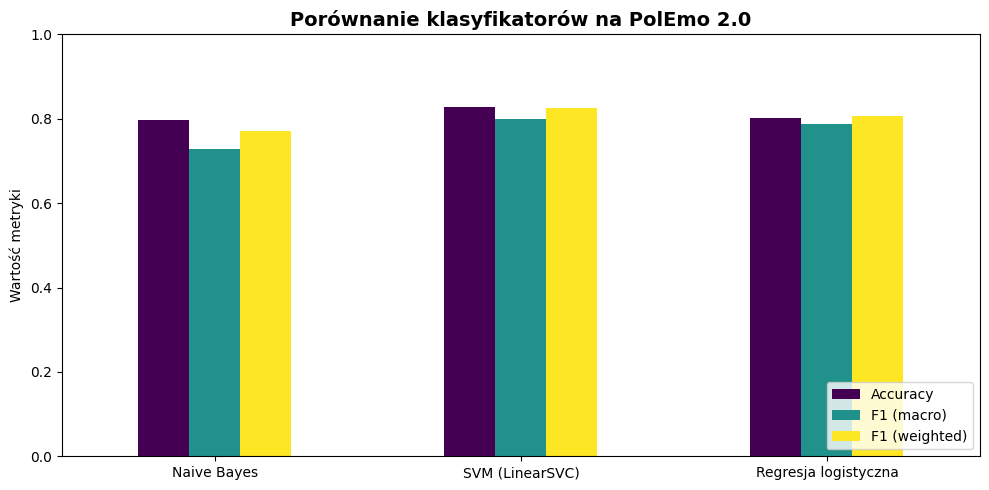

In [ ]:
# Wizualizacja porównania
fig, ax = plt.subplots(figsize=(10, 5))
results_df.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title('Porównanie klasyfikatorów na PolEmo 2.0', fontsize=14, fontweight='bold')
ax.set_ylabel('Wartość metryki')
ax.set_ylim(0, 1.0)
ax.legend(loc='lower right')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


# 9. Macierz pomyłek (Confusion Matrix)

Macierz pomyłek pokazuje, jak model klasyfikuje dokumenty względem prawdziwych etykiet — pozwala zidentyfikować, które klasy są najczęściej mylone.


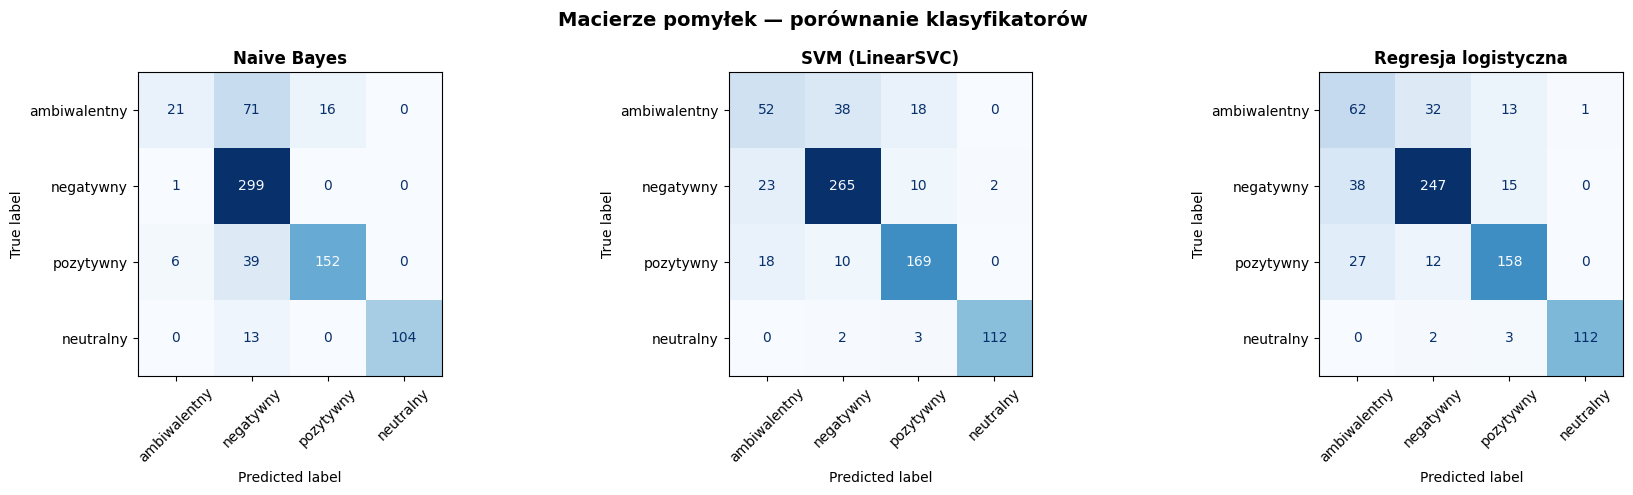

In [ ]:
# Macierze pomyłek dla wszystkich modeli
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_preds = [
    ('Naive Bayes', y_pred_nb),
    ('SVM (LinearSVC)', y_pred_svm),
    ('Regresja logistyczna', y_pred_lr)
]

# Ustalamy stałą kolejność etykiet
all_labels = sorted(np.unique(np.concatenate([y_test, y_pred_nb, y_pred_svm, y_pred_lr])))
display_labels = [label_names.get(l, l) for l in all_labels]

for ax, (name, y_pred) in zip(axes, models_preds):
    cm = confusion_matrix(y_test, y_pred, labels=all_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Macierze pomyłek — porównanie klasyfikatorów', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# 10. Analiza błędów

Systematyczna analiza błędnych predykcji pozwala zrozumieć słabości modelu i zaplanować poprawki.


In [ ]:
# Analiza błędów najlepszego modelu (SVM)
y_pred_best = y_pred_svm

# Znajdź błędne predykcje
mask_errors = y_test != y_pred_best
errors_text = X_test[mask_errors]
errors_true = y_test[mask_errors]
errors_pred = y_pred_best[mask_errors]

error_df = pd.DataFrame({
    'tekst': errors_text,
    'prawdziwa_etykieta': [label_names.get(t, t) for t in errors_true],
    'predykcja': [label_names.get(p, p) for p in errors_pred]
})

print(f"Liczba błędnych predykcji: {len(error_df)} / {len(y_test)} "
      f"({len(error_df)/len(y_test)*100:.1f}%)")
print()

# Najczęstsze typy pomyłek
print("Najczęstsze typy pomyłek (prawdziwa → predykcja):")
confusion_pairs = error_df.groupby(['prawdziwa_etykieta', 'predykcja']).size()
confusion_pairs = confusion_pairs.sort_values(ascending=False)
print(confusion_pairs.head(10).to_string())


Liczba błędnych predykcji: 124 / 722 (17.2%)

Najczęstsze typy pomyłek (prawdziwa → predykcja):
prawdziwa_etykieta  predykcja   
ambiwalentny        negatywny       38
negatywny           ambiwalentny    23
ambiwalentny        pozytywny       18
pozytywny           ambiwalentny    18
negatywny           pozytywny       10
pozytywny           negatywny       10
neutralny           pozytywny        3
negatywny           neutralny        2
neutralny           negatywny        2


In [ ]:
# Przykłady błędnych predykcji
print("Losowa próbka błędnych predykcji:")
print("=" * 80)
sample = error_df.sample(min(5, len(error_df)), random_state=42)
for _, row in sample.iterrows():
    print(f"PRAWDA: {row['prawdziwa_etykieta']} | PREDYKCJA: {row['predykcja']}")
    print(f"TEKST: {row['tekst'][:250]}...")
    print("-" * 80)


Losowa próbka błędnych predykcji:
PRAWDA: pozytywny | PREDYKCJA: negatywny
TEKST: niesamowity lekarz jego zaangażowanie jest niewiarygodne nigdy nie spotkał em lekarza z takim poziomem empatii i uprzejmości jak dr sarosiek zadzwonił em do niego w lutym że mam cm nasieniaka zaprosił mnie na wizytę na następny dzień w sobotę bo powi...
--------------------------------------------------------------------------------
PRAWDA: ambiwalentny | PREDYKCJA: negatywny
TEKST: wystawię neutralną ocenę bo lekarz ma jednocześnie plusy i minusy mniej więcej na podobnym poziomie może lekarz ma wiedzę medyczną i umie dobrać odpowiednie zabiegi rehabilitacyjne ale z drugiej strony nie ma podejścia do pacjenta trafiła m na jego o...
--------------------------------------------------------------------------------
PRAWDA: pozytywny | PREDYKCJA: ambiwalentny
TEKST: ja na prawdę nie rozumiem osób które piszą o p doktor jako o osobie oschłej czy niekompetentnej jest to jawna niesprawiedliwość znam ją prywatnie 

# 11. Walidacja krzyżowa (Cross-Validation)

Walidacja krzyżowa daje bardziej wiarygodną ocenę modelu niż pojedynczy podział na trening/test.


In [ ]:
# Łączymy dane treningowe i walidacyjne do walidacji krzyżowej
X_cv = np.concatenate([X_train, X_val])
y_cv = np.concatenate([y_train, y_val])

print("Walidacja krzyżowa (5-fold, metryka: F1 macro)\n")

models = {
    'Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2), min_df=2, sublinear_tf=True)),
        ('clf', MultinomialNB(alpha=1.0))
    ]),
    'SVM (LinearSVC)': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2), min_df=2, sublinear_tf=True)),
        ('clf', LinearSVC(C=1.0, max_iter=10000, class_weight='balanced'))
    ]),
    'Regresja logistyczna': Pipeline([
        ('tfidf', TfidfVectorizer(max_features=20000, ngram_range=(1,2), min_df=2, sublinear_tf=True)),
        ('clf', LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced'))
    ])
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_cv, y_cv, cv=5, scoring='f1_macro', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:25s} → F1 macro: {scores.mean():.4f} ± {scores.std():.4f}")


Walidacja krzyżowa (5-fold, metryka: F1 macro)

Naive Bayes               → F1 macro: 0.6722 ± 0.0757
SVM (LinearSVC)           → F1 macro: 0.7838 ± 0.0529
Regresja logistyczna      → F1 macro: 0.7765 ± 0.0677


# 12. Dobór hiperparametrów — GridSearchCV

Systematyczne przeszukiwanie siatki hiperparametrów pozwala znaleźć optymalną konfigurację pipeline'u.


In [ ]:
# GridSearchCV na pipeline SVM
pipeline_grid = Pipeline([
    ('tfidf', TfidfVectorizer(min_df=2)),
    ('clf', LinearSVC(max_iter=10000, class_weight='balanced'))
])

param_grid = {
    'tfidf__max_features': [10000, 20000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__sublinear_tf': [True, False],
    'clf__C': [0.1, 1.0, 10.0]
}

grid_search = GridSearchCV(
    pipeline_grid,
    param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_cv, y_cv)

print(f"\nNajlepsze parametry: {grid_search.best_params_}")
print(f"Najlepszy F1 macro (CV): {grid_search.best_score_:.4f}")


Fitting 3 folds for each of 24 candidates, totalling 72 fits

Najlepsze parametry: {'clf__C': 1.0, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True}
Najlepszy F1 macro (CV): 0.7809


In [ ]:
# Ewaluacja najlepszego modelu z GridSearch na zbiorze testowym
y_pred_best_gs = grid_search.best_estimator_.predict(X_test)

print("=" * 60)
print("NAJLEPSZY MODEL (GridSearch) — Raport klasyfikacji")
print("=" * 60)
print(classification_report(y_test, y_pred_best_gs))


NAJLEPSZY MODEL (GridSearch) — Raport klasyfikacji
                       precision    recall  f1-score   support

    __label__meta_amb       0.52      0.49      0.50       108
__label__meta_minus_m       0.84      0.87      0.85       300
 __label__meta_plus_m       0.85      0.85      0.85       197
   __label__meta_zero       0.98      0.96      0.97       117

             accuracy                           0.82       722
            macro avg       0.80      0.79      0.80       722
         weighted avg       0.82      0.82      0.82       722



# 13. Interpretacja modelu — najważniejsze cechy

Analiza wag modelu pozwala zrozumieć, które słowa (cechy TF-IDF) najsilniej wpływają na klasyfikację.


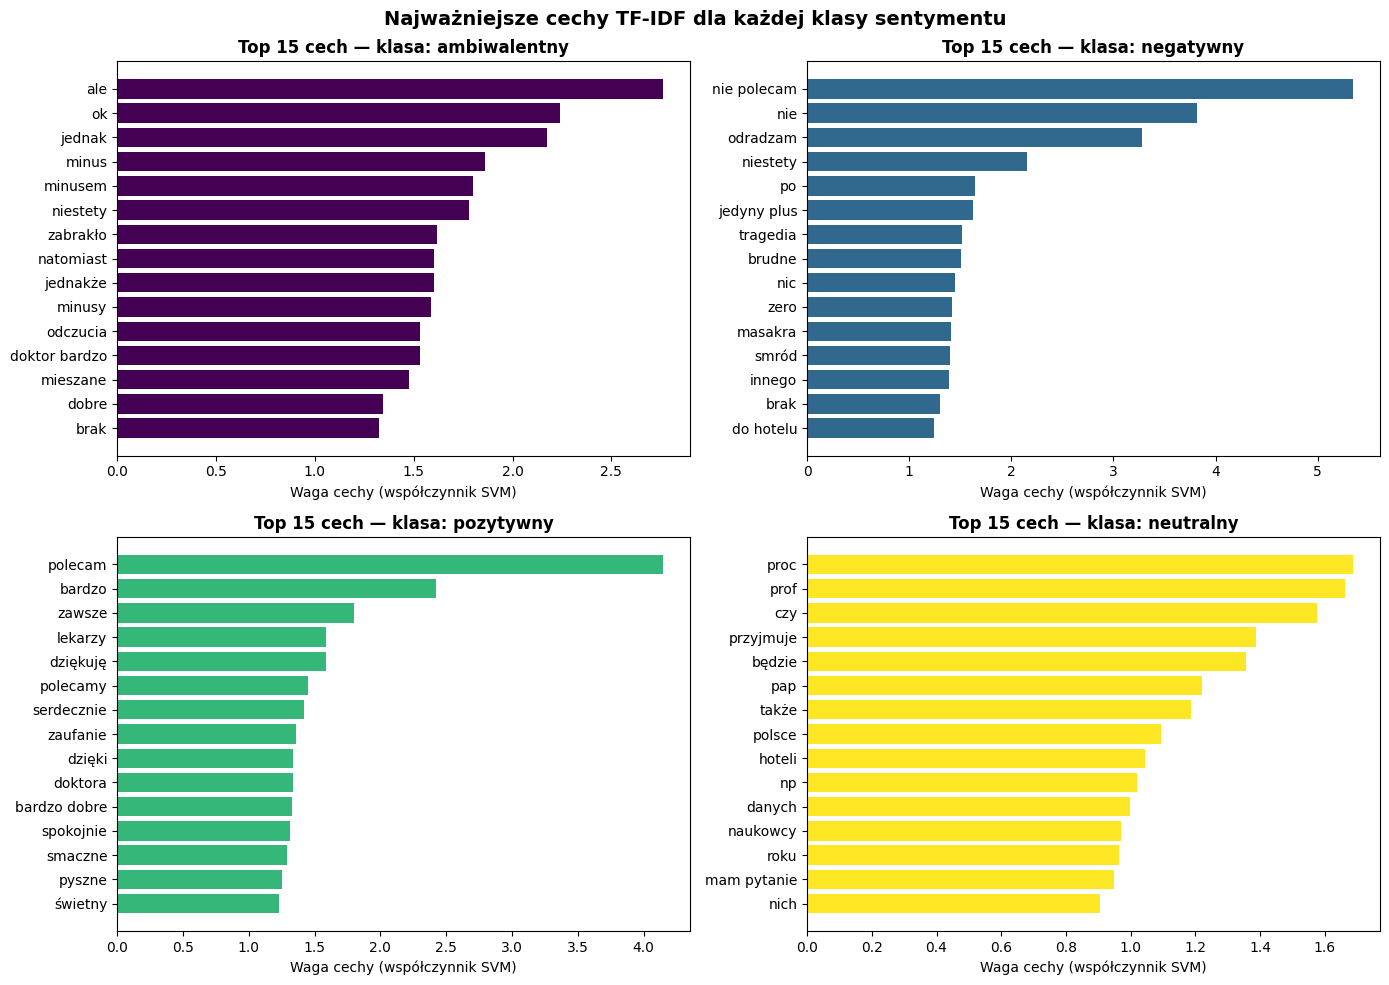

In [ ]:
# Najważniejsze cechy dla każdej klasy (na modelu SVM)
feature_names = pipeline_svm.named_steps['tfidf'].get_feature_names_out()
coefs = pipeline_svm.named_steps['clf'].coef_
classes = pipeline_svm.named_steps['clf'].classes_

n_top = 15
n_classes = len(classes)
n_cols = 2
n_rows = (n_classes + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for idx, class_label in enumerate(classes):
    ax = axes[idx]
    top_indices = np.argsort(coefs[idx])[-n_top:]
    top_features = feature_names[top_indices]
    top_weights = coefs[idx][top_indices]

    readable = label_names.get(class_label, class_label)
    ax.barh(range(n_top), top_weights, color=plt.cm.viridis(idx / max(n_classes - 1, 1)))
    ax.set_yticks(range(n_top))
    ax.set_yticklabels(top_features)
    ax.set_title(f'Top {n_top} cech — klasa: {readable}', fontweight='bold')
    ax.set_xlabel('Waga cechy (współczynnik SVM)')

# Ukryj puste osie jeśli nieparzysta liczba klas
for idx in range(n_classes, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Najważniejsze cechy TF-IDF dla każdej klasy sentymentu',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


# 14. Predykcja na nowych tekstach

Gotowy pipeline może klasyfikować dowolne polskie teksty.


In [ ]:
# Testowanie na własnych przykładach
nowe_teksty = [
    "Świetny lekarz, bardzo profesjonalny i kulturalny. Polecam gorąco!",
    "Hotel był brudny, jedzenie okropne, nigdy więcej.",
    "Wizyta u lekarza przebiegła bez problemów, nic szczególnego.",
    "Z jednej strony obsługa miła, ale pokoje wymagają remontu.",
    "Najgorszy hotel w jakim byłem. Karaluchy w łazience!",
    "Pani doktor poświęciła mi dużo czasu i dokładnie wszystko wyjaśniła."
]

# Preprocessing
nowe_teksty_processed = [preprocess_text(t) for t in nowe_teksty]

# Predykcja z najlepszym modelem (SVM)
predykcje = pipeline_svm.predict(nowe_teksty_processed)

print("Predykcje sentymentu na nowych tekstach:")
print("=" * 70)
for tekst, pred in zip(nowe_teksty, predykcje):
    readable = label_names.get(pred, pred)
    print(f"[{readable:>13s}]  {tekst}")


Predykcje sentymentu na nowych tekstach:
[    pozytywny]  Świetny lekarz, bardzo profesjonalny i kulturalny. Polecam gorąco!
[    negatywny]  Hotel był brudny, jedzenie okropne, nigdy więcej.
[    negatywny]  Wizyta u lekarza przebiegła bez problemów, nic szczególnego.
[    negatywny]  Z jednej strony obsługa miła, ale pokoje wymagają remontu.
[    negatywny]  Najgorszy hotel w jakim byłem. Karaluchy w łazience!
[    pozytywny]  Pani doktor poświęciła mi dużo czasu i dokładnie wszystko wyjaśniła.


In [ ]:
# Predykcja z prawdopodobieństwami (regresja logistyczna)
probas = pipeline_lr.predict_proba(nowe_teksty_processed)

print("Prawdopodobieństwa przynależności do klas (regresja logistyczna):")
print("=" * 80)
klasy = pipeline_lr.classes_
for tekst, proba in zip(nowe_teksty, probas):
    print(f"\nTekst: {tekst[:60]}...")
    for klasa, p in zip(klasy, proba):
        readable = label_names.get(klasa, klasa)
        bar = '█' * int(p * 30)
        print(f"  {readable:>13s}: {p:.3f} {bar}")


Prawdopodobieństwa przynależności do klas (regresja logistyczna):

Tekst: Świetny lekarz, bardzo profesjonalny i kulturalny. Polecam g...
   ambiwalentny: 0.035 █
      negatywny: 0.032 
      pozytywny: 0.903 ███████████████████████████
      neutralny: 0.029 

Tekst: Hotel był brudny, jedzenie okropne, nigdy więcej....
   ambiwalentny: 0.103 ███
      negatywny: 0.732 █████████████████████
      pozytywny: 0.104 ███
      neutralny: 0.062 █

Tekst: Wizyta u lekarza przebiegła bez problemów, nic szczególnego....
   ambiwalentny: 0.195 █████
      negatywny: 0.418 ████████████
      pozytywny: 0.265 ███████
      neutralny: 0.122 ███

Tekst: Z jednej strony obsługa miła, ale pokoje wymagają remontu....
   ambiwalentny: 0.502 ███████████████
      negatywny: 0.200 ██████
      pozytywny: 0.227 ██████
      neutralny: 0.071 ██

Tekst: Najgorszy hotel w jakim byłem. Karaluchy w łazience!...
   ambiwalentny: 0.145 ████
      negatywny: 0.514 ███████████████
      pozytywny: 0.174 █████
   

---

# Ćwiczenia — inne datasety polskie



---


## Ćwiczenie A: Allegro Reviews

**Opis datasetu:** Allegro Reviews to zbiór 11 588 recenzji produktów napisanych po polsku, pobranych z popularnego serwisu e-commerce Allegro.pl. Każda recenzja zawiera co najmniej 50 słów i ma ocenę w skali od 1 (negatywna) do 5 (pozytywna).

**Zadanie:** Zbuduj pełny pipeline klasycznej klasyfikacji sentymentu (TF-IDF + klasyfikator) na tym datasecie. Porównaj wyniki Naive Bayes, SVM i regresji logistycznej.

**Uwaga:** Zbiór testowy nie zawiera etykiet (ocen), dlatego do ewaluacji użyj zbioru walidacyjnego (`validation`).

### Krok 1 — Załadowanie danych


In [ ]:
# ============================================================
# Ćwiczenie A: Allegro Reviews — ładowanie datasetu
# ============================================================
!pip install datasets -q

from datasets import load_dataset
import pandas as pd

# Ładowanie datasetu z Hugging Face
dataset_allegro = load_dataset("allegro/klej-allegro-reviews")

print("Struktura datasetu Allegro Reviews:")
print(dataset_allegro)
print()

# Konwersja do DataFrame
df_allegro_train = pd.DataFrame(dataset_allegro['train'])
df_allegro_val = pd.DataFrame(dataset_allegro['validation'])

print("Kolumny:", df_allegro_train.columns.tolist())
print(f"Zbiór treningowy: {len(df_allegro_train)} recenzji")
print(f"Zbiór walidacyjny: {len(df_allegro_val)} recenzji")
print()

# Podgląd danych
print("Przykładowy rekord:")
print(df_allegro_train.iloc[0])
print()

# Rozkład ocen (rating: 1-5)
print("Rozkład ocen w zbiorze treningowym:")
print(df_allegro_train['rating'].value_counts().sort_index())


Struktura datasetu Allegro Reviews:
DatasetDict({
    train: Dataset({
        features: ['text', 'rating'],
        num_rows: 9577
    })
    validation: Dataset({
        features: ['text', 'rating'],
        num_rows: 1002
    })
    test: Dataset({
        features: ['text', 'rating'],
        num_rows: 1006
    })
})

Kolumny: ['text', 'rating']
Zbiór treningowy: 9577 recenzji
Zbiór walidacyjny: 1002 recenzji

Przykładowy rekord:
text      Jako do ceny dobra. Przyssawka mogłaby być lep...
rating                                                  3.0
Name: 0, dtype: object

Rozkład ocen w zbiorze treningowym:
rating
1.0    1733
2.0    1069
3.0    1208
4.0    1644
5.0    3923
Name: count, dtype: int64


### Wskazówki do realizacji:

1. Kolumna z tekstem to `text`, a etykieta to `rating` (wartości 1–5).
2. Możesz uprościć zadanie do klasyfikacji binarnej: oceny 1–2 → negatywne, 4–5 → pozytywne (odrzucając oceny 3 jako neutralne).
3. Zastosuj ten sam pipeline co w części głównej: preprocessing → TF-IDF → klasyfikator.
4. Porównaj wyniki z wynikami na PolEmo 2.0 — czy klasyfikacja na 5 klasach jest trudniejsza?
5. Użyj `class_weight='balanced'` w SVM i regresji logistycznej, ponieważ klasy mogą być niezbalansowane.


## Ćwiczenie B: Ermlab Opineo Dataset

**Opis datasetu:** Dataset zebrany przez firmę Ermlab z serwisu Opineo.pl (polskie recenzje sklepów internetowych), Twittera (polskie hashtagi polityczne), projektu HateSpeech PAN oraz komentarzy z YouTube. Zawiera trzy klasy sentymentu: pozytywny, neutralny i negatywny.

**Zadanie:** Pobierz dataset, załaduj go do Colab i zbuduj pipeline klasyfikacji sentymentu.

### Krok 1 — Załadowanie danych

Dataset jest udostępniony na Google Drive. Pobieramy go za pomocą `gdown`.


In [ ]:
# ============================================================
# Ćwiczenie C: Ermlab Opineo Dataset — ładowanie datasetu
# ============================================================
!pip install gdown -q

import gdown
import zipfile
import os
import pandas as pd

# Pobieranie datasetu z Google Drive
# Źródło: https://github.com/Ermlab/pl-sentiment-analysis
file_id = "1vXqUEBjUHGGy3vV2dA7LlvBjjZlQnl0D"
output_path = "ermlab_dataset.zip"

gdown.download(f"https://drive.google.com/uc?id={file_id}", output_path, quiet=False)

# Rozpakowanie archiwum
with zipfile.ZipFile(output_path, 'r') as zip_ref:
    zip_ref.extractall("ermlab_data")

# Wylistowanie plików
print("\nPliki w archiwum:")
for root, dirs, files in os.walk("ermlab_data"):
    for f in files:
        filepath = os.path.join(root, f)
        print(f"  {filepath} ({os.path.getsize(filepath) / 1024:.0f} KB)")


Downloading...
From (original): https://drive.google.com/uc?id=1vXqUEBjUHGGy3vV2dA7LlvBjjZlQnl0D
From (redirected): https://drive.google.com/uc?id=1vXqUEBjUHGGy3vV2dA7LlvBjjZlQnl0D&confirm=t&uuid=78544173-8cc0-4099-90da-1b253cef0d98
To: /content/ermlab_dataset.zip
100%|██████████| 30.4M/30.4M [00:00<00:00, 46.7MB/s]



Pliki w archiwum:
  ermlab_data/polish_sentiment_dataset.csv (93009 KB)


In [ ]:
# Załadowanie datasetu
# Ermlab dataset to plik CSV z kolumnami: description, rate
# rate: 0=negatywny, 1=neutralny, 2=pozytywny

import glob

# Szukamy pliku CSV w rozpakowanym archiwum
csv_files = glob.glob("ermlab_data/**/*.csv", recursive=True)
print("Znalezione pliki CSV:", csv_files)

# Ładujemy dane
if csv_files:
    df_ermlab = pd.read_csv(csv_files[0], sep=None, engine='python')
    print(f"\nZaładowano: {csv_files[0]}")
    print(f"Rozmiar: {len(df_ermlab)} wierszy")
    print(f"Kolumny: {df_ermlab.columns.tolist()}")
    print(f"\nPierwsze wiersze:")
    print(df_ermlab.head())
    print(f"\nRozkład etykiet:")
    # Sprawdzamy możliwe nazwy kolumny z etykietą
    for col in ['rate', 'label', 'sentiment', 'rating']:
        if col in df_ermlab.columns:
            print(df_ermlab[col].value_counts().sort_index())
            break
else:
    print("Brak plików CSV — sprawdź strukturę archiwum powyżej.")
    print("Może być konieczne dostosowanie ścieżki lub separatora.")


Znalezione pliki CSV: ['ermlab_data/polish_sentiment_dataset.csv']

Załadowano: ermlab_data/polish_sentiment_dataset.csv
Rozmiar: 936883 wierszy
Kolumny: ['description', 'length', 'rate']

Pierwsze wiersze:
                                         description  length  rate
0            Polecam nie pierwszy i nie ostatni raz!    39.0   1.0
1  Bardzo dobra komunikacja sms i telefoniczna. Z...   121.0   1.0
2  Polecam zakupy w tym sklepie. Są dostępne częś...    87.0   1.0
3                                                  0     0.0   0.0
4   Jestem w pełni zadowolona z przebiegu transakcji    48.0   1.0

Rozkład etykiet:
rate
-1.0    184020
 0.0     18547
 1.0    734282
Name: count, dtype: int64


### Wskazówki do realizacji:

1. Dataset Ermlab zawiera kolumny z opisem/recenzją (`description`) i etykietą sentymentu (`rate`): 0 (negatywny), 1 (neutralny), 2 (pozytywny).
2. Dane pochodzą z różnych źródeł (Opineo, Twitter, YouTube), co czyni je bardziej zróżnicowanymi niż PolEmo 2.0.
3. Zastosuj pipeline klasyfikacji jak w części głównej. Pamiętaj o podziale na zbiór treningowy i testowy (`train_test_split` ze stratyfikacją), ponieważ ten dataset nie ma wbudowanego podziału.
4. Porównaj wyniki z wynikami na PolEmo 2.0 — czy różnorodność źródeł danych wpływa na jakość klasyfikacji?




# Bonus

## Hackathony, konkursy i zasoby związane z analizą sentymentu (wybrane)

### 🏆 Konkursy PolEval — zadania analizy sentymentu

PolEval to coroczna kampania ewaluacyjna narzędzi NLP dla języka polskiego, wzorowana na SemEval. Kilka edycji zawierało zadania bezpośrednio dotyczące analizy sentymentu:

- **PolEval 2017 — Task 2: Sentiment Analysis**
  Klasyfikacja sentymentu na poziomie fraz w polskim treebanku zależnościowym (Polish Sentiment Treebank).
  [http://2017.poleval.pl/index.php/tasks/](http://2017.poleval.pl/index.php/tasks/)

- **PolEval 2024 — Task 2: Emotion and Sentiment Recognition**
  Rozpoznawanie emocji (koło Plutchika) i sentymentu w polskich recenzjach konsumenckich na poziomie zdań i całych tekstów.
  [https://2024.poleval.pl/tasks/task2](https://2024.poleval.pl/tasks/task2)

- **PolEval 2025 — Task 4: Polish Speech Emotion Recognition Challenge**
  Rozpoznawanie emocji w polskiej mowie (cross-lingual, bez polskich danych treningowych).
  [https://poleval.pl/tasks/task4](https://poleval.pl/tasks/task4)

- **Strona główna PolEval (archiwum wszystkich edycji 2017–2025):**
  [https://poleval.pl/](https://poleval.pl/)

- **Publikacje PolEval 2024 (w tym artykuły o rozwiązaniach sentymentu):**
  [http://poleval.pl/publication/](http://poleval.pl/publication/)

---

### 📊 Benchmarki NLP z zadaniami analizy sentymentu

- **KLEJ Benchmark** — 9 zadań NLU dla języka polskiego, w tym **PolEmo2.0-IN**, **PolEmo2.0-OUT** (analiza sentymentu) i **Allegro Reviews** (regresja ocen 1–5). Posiada publiczny leaderboard.
  [https://klejbenchmark.com/](https://klejbenchmark.com/)
  Zadania: [https://klejbenchmark.com/tasks/](https://klejbenchmark.com/tasks/)

- **LEPISZCZE Benchmark** — nowszy benchmark NLP od CLARIN-PL z datasetu `clarin-pl/polemo2-official` (analiza sentymentu) i innymi zadaniami. Publiczny leaderboard z ciągłym zgłaszaniem wyników.
  [https://lepiszcze.clarin-pl.eu/](https://lepiszcze.clarin-pl.eu/)
  GitHub: [https://github.com/CLARIN-PL/LEPISZCZE](https://github.com/CLARIN-PL/LEPISZCZE)

---

### 📁 Datasety na Kaggle — polski sentyment

- **Polish Sentiment Analysis Dataset** (Kaggle, 2023) — dataset do analizy sentymentu po polsku.
  [https://www.kaggle.com/datasets/yaroslavbanchenko/polish-sentiment-analysis](https://www.kaggle.com/datasets/yaroslavbanchenko/polish-sentiment-analysis)

---

### 🏗️ Hackathony w Polsce z komponentem NLP/AI

- **HackYeah** — największy hackathon stacjonarny w Europie, organizowany corocznie w Polsce. Niektóre edycje zawierały zadania z kategorii AI/NLP.
  [https://hackyeah.pl/](https://hackyeah.pl/)

- **Legal Hackathon 2025 (Wolters Kluwer)** — wyzwania obejmowały m.in. wykorzystanie NLP do analizy sentymentu i przetwarzania tekstów prawnych.
  [https://www.wolterskluwer.com/pl-pl/solutions/legal-hackathon/wyzwania-technologie-legaltech](https://www.wolterskluwer.com/pl-pl/solutions/legal-hackathon/wyzwania-technologie-legaltech)


---

### 📚 Publiczne datasety i repozytoria do ćwiczeń

- **PolEmo 2.0 (KLEJ):** [https://huggingface.co/datasets/allegro/klej-polemo2-in](https://huggingface.co/datasets/allegro/klej-polemo2-in)
- **PolEmo 2.0 Official (CLARIN-PL):** [https://huggingface.co/datasets/clarin-pl/polemo2-official](https://huggingface.co/datasets/clarin-pl/polemo2-official)
- **Allegro Reviews:** [https://huggingface.co/datasets/allegro/klej-allegro-reviews](https://huggingface.co/datasets/allegro/klej-allegro-reviews)
- **Ermlab Opineo Dataset (Google Drive):** [https://drive.google.com/file/d/1vXqUEBjUHGGy3vV2dA7LlvBjjZlQnl0D/view](https://drive.google.com/file/d/1vXqUEBjUHGGy3vV2dA7LlvBjjZlQnl0D/view)
  GitHub projektu: [https://github.com/Ermlab/pl-sentiment-analysis](https://github.com/Ermlab/pl-sentiment-analysis)
- **WCCRS (CLARIN-PL):** [https://clarin-pl.eu/dspace/handle/11321/700](https://clarin-pl.eu/dspace/handle/11321/700)
- **Polish Sentiment Treebank (IPI PAN):** [http://zil.ipipan.waw.pl/TreebankWydzwieku](http://zil.ipipan.waw.pl/TreebankWydzwieku)

---

### 🔗 Zbiorcze listy zasobów NLP dla polskiego

- **awesome-nlp-polish** — obszerny katalog datasetów, modeli i narzędzi NLP dla języka polskiego:
  [https://github.com/ksopyla/awesome-nlp-polish](https://github.com/ksopyla/awesome-nlp-polish)

- **polish-nlp-resources (sdadas)** — pretrenowane modele i zasoby językowe:
  [https://github.com/sdadas/polish-nlp-resources](https://github.com/sdadas/polish-nlp-resources)

- **CLIP IPI PAN — zasoby językowe i benchmarki:**
  [https://clip.ipipan.waw.pl/LRT](https://clip.ipipan.waw.pl/LRT)
  [https://clip.ipipan.waw.pl/benchmarks](https://clip.ipipan.waw.pl/benchmarks)